# Exploration 06 — quantum regression models vs classical models (M4 on simulators)

> **Exploratory** (docs/EVALUATION_RULES.md, "Exploration"). **Inputs:** Z and R only (the all_legal descriptors of notebook 02,
> reduced as in notebook 03). **Data:** the Track B training sets S_(s,N), N = 100, 300, 1000 × seeds 0, 1, 2, tuned
> inside each one, and the development sets `dev` (familiar formulas) and `dev_unseen` (formulas absent from every
> training set). No test set is read. **Quantum:** exact statevector simulation on a CPU; nothing runs on IBM
> hardware. Finite shots, hardware noise and cost are notebook 07.

**The question.** The brief asks for a quantum regression model compared fairly with classical ones as the number of
labels grows. Notebook 04 built two classical references: **Track A**, the most accurate model from Z and R at any
training size, and **Track B**, the same pipeline scaled to what a quantum model can use (N ≤ 1000 and k = 10
inputs). This notebook builds the quantum models and reports every one against both.

**What the quantum models are** (for readers who know ML but not quantum computing):
- A molecule's k numbers (its descriptors, compressed to k inputs by partial least squares and standardized) become
  k **rotation angles** γ·x of a fixed circuit, the *encoding* U(x). Running it on |0…0⟩ prepares an n-qubit state
  |ψ(x)⟩: a unit vector of 2ⁿ complex amplitudes. Nothing in the circuit is trained.
- **Quantum kernel ridge (QKRR)** uses the **fidelity** k(x, x′) = |⟨ψ(x)|ψ(x′)⟩|² as the kernel of ordinary kernel
  ridge regression: the classical RBF kernel ridge with the similarity swapped for a state overlap. On hardware each
  entry is measured with its own circuit. γ acts like an RBF bandwidth.
- The **projected quantum kernel (PQK)** compares only each qubit's own state (its Bloch vector ⟨X⟩, ⟨Y⟩, ⟨Z⟩) with an
  RBF kernel: 3 circuits per molecule instead of one per pair of molecules.
- The **team's quantum-feature ridge** (`models/quantum.py`, by yuyuko-s) measures ⟨Z⟩ on each qubit and fits ridge
  regression on those k numbers.

**Fairness** (DECISIONS.md, 2026-10-07, written before these results): identical training sets, folds, inputs,
target transform and clipping for every model; the quantum kernels go through a tuner that reproduces the classical
harness exactly when given the RBF kernel (unit-tested), with grids of the same size (88 candidates for QKRR and RBF
kernel ridge). The headline quantum model is chosen by CV inside the training sets, never on `dev`.

In [1]:
# Environment check: stops here, with setup instructions, unless this kernel is the project
# environment (README.md, "Setup"). Version differences from requirements.txt only warn.
try:
    from qm9dipole.provenance import check_environment
except ModuleNotFoundError as e:
    raise RuntimeError(
        "The qm9dipole package is not installed in this kernel's environment. Follow "
        "README.md (Setup), then select that environment as the notebook kernel."
    ) from e

print(check_environment())

environment OK: Python 3.12.14, 16 pinned packages checked, 0 differ; package and notebook are in the same checkout


In [2]:
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FixedLocator, NullFormatter, NullLocator
from qiskit.quantum_info import Statevector
from sklearn.metrics.pairwise import rbf_kernel

from qm9dipole import REPO_ROOT
from qm9dipole.complexity import kernel_ridge_df, participation_ratio
from qm9dipole.data import PROCESSED_DIR, load_qm9_table
from qm9dipole.descriptors import MODEL_DESCRIPTORS, feature_frame, raw_coordinates
from qm9dipole.evaluate import clip_predictions, dev_curve
from qm9dipole.explore import feature_sets, load_catalog, load_features, load_preprocessing
from qm9dipole.invariance import TRANSFORMS
from qm9dipole.models import classical
from qm9dipole.models.fitters import MeanFitter, TabularFitter
from qm9dipole.models.qsim import BatchedCircuit, fidelity_kernel
from qm9dipole.models.quantum import QuantumFeatureTransformer, build_encoding_circuit
from qm9dipole.models.quantum_kernel import (
    FidelityKernel, KernelRidgeFitter, ProjectedKernel, default_qubits, feature_prefix, kernel_spectrum,
    kernel_target_alignment, offdiag_stats, quantum_gamma_grid, quantum_ridge_build, zz_readout_closed_form,
)
from qm9dipole.preprocess import target_transformer
from qm9dipole.plots import (AXIS, INK_SECONDARY, MODEL_COLORS, MODEL_LABELS, MUTED, SEQUENTIAL, SERIES, SURFACE,
                             model_style, use_style)
from qm9dipole.provenance import RESULTS_DIR, git_hash, save_result
from qm9dipole.splits import load_splits
from qm9dipole.provenance import figure_file, results_file

# Development switch: QM9DIPOLE_SMOKE=1 runs one seed at N = 100 with small axes. Unset for real runs.
SMOKE = os.environ.get("QM9DIPOLE_SMOKE") == "1"

use_style()
FIG_DIR = REPO_ROOT / "figures"
features = load_features()
SETS = feature_sets(load_catalog())
PRE = load_preprocessing()
SC_B, TG_B = PRE["scaling"]["track_b"], PRE["target"]["track_b"]
RED = (PRE["reduction"]["method"], int(PRE["reduction"]["k"]))
RED_NAME = f"{RED[0]}{RED[1]}"
splits = load_splits()
y = features["mu"]
EVAL = {"dev": splits.dev, "dev_unseen": splits.dev_unseen}
SIZES = [100] if SMOKE else list(splits.track_b_sizes)
SEEDS = [0] if SMOKE else list(splits.train)
NMAX = max(SIZES)
TRACK_B = {s: {n: splits.train[s][n] for n in SIZES} for s in SEEDS}
# float64 throughout: the feature table stores float32, and some sklearn steps compute in their input dtype.
XA, XC = features[SETS["all_legal"]].astype(np.float64), features[SETS["composition"]].astype(np.float64)
CACHE = None if SMOKE else PROCESSED_DIR / "cache" / "explore06" / git_hash(short=True)
track_a = pd.read_csv(results_file("explore04_track_a.csv"))
track_b = pd.read_csv(results_file("explore04_track_b.csv"))
print(f"Track B inputs (notebook 03): scaling {SC_B}, target {TG_B}, reduction {RED[0]} to k = {RED[1]}")
print(f"training sizes {SIZES} × seeds {SEEDS}; dev {len(splits.dev):,}, dev_unseen {len(splits.dev_unseen):,} molecules")

Track B inputs (notebook 03): scaling yeo_johnson, target sqrt, reduction pls to k = 10
training sizes [100, 300, 1000] × seeds [0, 1, 2]; dev 5,000, dev_unseen 4,183 molecules


## 1. The circuits

The three team encoders (`build_encoding_circuit`, by yuyuko-s), drawn for k = 4 inputs. Each input x_i enters as a
rotation angle γ·x_i; `reps` repeats the whole upload.
- **ZZ map** (`zz`, Qiskit's `zz_feature_map`, linear entanglement): Hadamards, phase gates P(2γx_i), and for each
  neighbouring pair a CX–P(2(π − γx_i)(π − γx_j))–CX block that writes the *product* of two inputs into the phase. Two
  passes. k qubits.
- **RY + CZ** (`ry`): RY(γx_i) then a fixed RX(π/4) on every qubit, a chain of CZ gates between passes. k qubits.
- **RY-RZ** (`ry_rz`): two inputs per qubit (RY then RZ), so k/2 qubits.
- The **product-state control** is `ry` with a single pass: no CZ ever acts, the qubits never become entangled, and the
  fidelity kernel is exactly the classical kernel Π cos²(γΔx_i/2). If a quantum kernel beats it, entanglement did
  something; if not, the circuit added nothing a classical kernel lacks.

In [3]:
for encoding, reps in [("zz", 2), ("ry", 2), ("ry_rz", 2), ("ry", 1)]:
    c = build_encoding_circuit(4, default_qubits(encoding, 4), encoding=encoding, reps=reps)
    ops = dict(c.count_ops())
    print(f"--- {encoding}, {reps} pass(es): {c.num_qubits} qubits, depth {c.depth()}, gates {ops}")
    print(c.draw(output="text", fold=120))

--- zz, 2 pass(es): 4 qubits, depth 19, gates {'p': 14, 'cx': 12, 'h': 8}
     ┌───┐┌───────────┐                                          ┌───┐         ┌───────────┐                    »
q_0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├─────────┤ P(2*x[0]) ├────────────────────»
     ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐└───┘         └───────────┘               ┌───┐»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■────────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐┌──────────────────────────────┐┌─┴─┐└───┘»
q_2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├┤ P((-π + x[1])*(-π + x[2])*2) ├┤ X ├──■──»
     ├───┤├───────────┤                                          └───┘└──────────────────────────────┘└───┘┌─┴─┐»
q_3: ┤ H ├┤ P(2*x[3]) ├────────────────────────────────────────────────────────────────────────────────────┤ X ├»
     └───┘└───

### 1b. Checking the simulator
Statevectors come from `models/qsim.py`, which evolves every molecule through the same Qiskit circuit at once. Here it
is checked against Qiskit's own `Statevector` on real inputs (20 development molecules, PLS inputs fit on S_(0,1000)),
and timed.

In [4]:
ids_fit = splits.train[0][NMAX]
pre = feature_prefix(SC_B, RED)
z_fit = target_transformer(TG_B).fit(y.loc[ids_fit].to_numpy()[:, None]).transform(y.loc[ids_fit].to_numpy()[:, None]).ravel()
pre.fit(XA.loc[ids_fit].to_numpy(), z_fit)
probe = pre.transform(XA.loc[splits.dev[:20]].to_numpy())
rows = []
for encoding in ("zz", "ry", "ry_rz"):
    circ = build_encoding_circuit(RED[1], default_qubits(encoding, RED[1]), encoding=encoding, reps=2)
    t = time.perf_counter()
    ref = np.stack([Statevector(circ.assign_parameters(0.4 * x)).data for x in probe])
    t_qiskit = (time.perf_counter() - t) / len(probe)
    bc = BatchedCircuit(circ)
    big = np.tile(probe, (50, 1))
    t = time.perf_counter()
    fast = bc.statevectors(0.4 * big)
    t_batched = (time.perf_counter() - t) / len(big)
    rows.append({"encoding": encoding, "qubits": circ.num_qubits,
                 "max |Δ amplitude|": np.abs(fast[:len(probe)] - ref).max(),
                 "max |Δ kernel|": np.abs(fidelity_kernel(fast[:len(probe)]) - fidelity_kernel(ref)).max(),
                 "Qiskit Statevector (ms/molecule)": 1e3 * t_qiskit, "batched (ms/molecule)": 1e3 * t_batched})
display(pd.DataFrame(rows).set_index("encoding").style.format({"max |Δ amplitude|": "{:.1e}", "max |Δ kernel|": "{:.1e}",
        "Qiskit Statevector (ms/molecule)": "{:.2f}", "batched (ms/molecule)": "{:.3f}"}))

,qubits,max |Δ amplitude|,max |Δ kernel|,Qiskit Statevector (ms/molecule),batched (ms/molecule)
encoding,,,,,
zz,10,6.3e-14,2.2e-15,4.80,0.400
ry,10,2.4e-16,3.3e-15,3.44,0.294
ry_rz,5,6.5e-16,3.1e-15,1.67,0.012


## 2. Main comparison: every quantum model and its classical twins on the same 10 inputs

At each (seed, N): the mean baseline; **ridge** and **RBF kernel ridge** (the matched classical twins, identical to
notebook 04's Track B `pls10` models); QKRR with the three encoders and the product-state control; the projected
quantum kernel; and the team's quantum-feature ridge. All see the same Yeo-Johnson → PLS(10) → standardized inputs,
fit inside every fold, and the same √|μ| target.

In [5]:
QUANTUM_KERNELS = {
    "qkrr": FidelityKernel("zz", 2),
    "qkrr_ry": FidelityKernel("ry", 2),
    "qkrr_ryrz": FidelityKernel("ry_rz", 2),
    "qkrr_product": FidelityKernel("ry", 1),
    "pqk": ProjectedKernel("zz", 2),
}
QMODELS = [*QUANTUM_KERNELS, "qridge"]
CONTROLS = ["qkrr_product"]  # a classical kernel in quantum form: reported, never the headline


def classical_twins(seed, frame, reduction, models=("ridge", "rbf_krr")):
    out = {}
    for m in models:
        est, grid = classical.build(m, seed, scaling=SC_B, target=TG_B, reduction=reduction, n_features=frame.shape[1])
        out[m] = TabularFitter(frame, est, grid, seed, cv_max_n=NMAX)
    return out


def make_main(seed, n):
    out = {"mean": MeanFitter(), **classical_twins(seed, XA, RED)}
    for name, kernel in QUANTUM_KERNELS.items():
        out[name] = KernelRidgeFitter(XA, kernel, seed, scaling=SC_B, target=TG_B, reduction=RED, cv_max_n=NMAX)
    est, grid = quantum_ridge_build(seed, SC_B, TG_B, RED, XA.shape[1])
    out["qridge"] = TabularFitter(XA, est, grid, seed, cv_max_n=NMAX)
    return out


def tidy(frame, features_name):
    frame = frame.copy()
    det = frame["details"].map(json.loads)
    frame["cv_mae_D"] = det.map(lambda d: d.get("tuning_mae_D", np.nan))
    frame["features"] = features_name
    return frame


start = time.perf_counter()
main, preds_main = dev_curve(make_main, TRACK_B, EVAL, y, cache_dir=CACHE, progress=False)
main = tidy(main, RED_NAME)
print(f"{main[['seed', 'n_train', 'model']].drop_duplicates().shape[0]} fits in {(time.perf_counter() - start) / 60:.1f} min")
_ = save_result(main, "explore06_main", reduction=list(RED), scaling=SC_B, target=TG_B, smoke=SMOKE,
                label="exploratory; Z, R only; Track B sets; quantum models exact statevector simulation; dev scores")

# The classical twins must reproduce notebook 04's Track B rows exactly (same code, data, folds and seeds).
ref = track_b[(track_b["features"] == RED_NAME) & track_b["model"].isin(["ridge", "rbf_krr"])]
ref = ref.set_index(["seed", "n_train", "model", "eval_set"])["mae_D"]
ours = main[main["model"].isin(["ridge", "rbf_krr"])].set_index(["seed", "n_train", "model", "eval_set"])["mae_D"]
common = ours.index.intersection(ref.index)
gap = (ours.loc[common] - ref.loc[common]).abs().max()
print(f"classical twins vs notebook 04 Track B: {len(common)} of {len(ours)} rows compared, max |Δ MAE| = {gap:.1e} D")
assert len(common) > 0 and gap < 1e-9, "the twins differ from notebook 04"

81 fits in 0.0 min
classical twins vs notebook 04 Track B: 36 of 36 rows compared, max |Δ MAE| = 1.1e-16 D


In [6]:
def mean_sd(frame, col):
    g = frame.groupby(["model", "n_train"])[col]
    return g.mean().unstack("n_train"), g.std().unstack("n_train")


ORDER = ["mean", "ridge", "rbf_krr", *QMODELS]
tables = []
for ev in EVAL:
    m, s = mean_sd(main[main["eval_set"] == ev], "mae_D")
    t = m.map("{:.3f}".format) + " ± " + s.fillna(0).map("{:.3f}".format)
    t.columns = [f"{ev} MAE, N={n}" for n in t.columns]
    tables.append(t)
cvm = main[main["eval_set"] == "dev"].groupby(["model", "n_train"])["cv_mae_D"].mean().unstack("n_train")
cvm.columns = [f"CV MAE, N={n}" for n in cvm.columns]
summary = pd.concat([cvm.map(lambda v: "—" if np.isnan(v) else f"{v:.3f}"), *tables], axis=1).loc[ORDER]
summary.index = summary.index.map(MODEL_LABELS)
display(summary.style.set_caption("Main comparison on PLS(10) inputs: MAE (D), mean ± sd over seeds"))

rm, _ = mean_sd(main[main["eval_set"] == "dev"], "rmse_D")
rt, _ = mean_sd(main[main["eval_set"] == "dev"], "rmse_below_tail_D")
r2, _ = mean_sd(main[main["eval_set"] == "dev"], "r2")
extra = pd.concat({"dev RMSE": rm, "dev RMSE below 9 D": rt, "dev R²": r2}, axis=1).loc[ORDER]
extra.index = extra.index.map(MODEL_LABELS)
display(extra.style.format("{:.3f}").set_caption("dev RMSE, RMSE without the |μ| ≥ 9 D tail, and R² (mean over seeds)"))

# Pre-registered headline: lowest mean CV MAE at the largest N, among the quantum configurations
# (the product-state control is a classical kernel, so it is not eligible).
cv_top = main[(main["n_train"] == NMAX) & (main["eval_set"] == "dev") & main["model"].isin([*QMODELS, "rbf_krr"])]
cv_top = cv_top.groupby("model")["cv_mae_D"].mean().sort_values()
HEAD = cv_top.drop(index=[*CONTROLS, "rbf_krr"]).index[0]
display(cv_top.rename(index=MODEL_LABELS).to_frame("mean CV MAE (D)").style.format("{:.4f}")
        .set_caption(f"choosing the headline quantum model: CV inside S_(s,{NMAX}) only (RBF kernel ridge and the "
                     "product-state control shown for reference, not eligible)"))
print(f"headline quantum model: {MODEL_LABELS[HEAD]} ({HEAD})")
chosen = main[main["model"].isin(QMODELS) & (main["eval_set"] == "dev")][["seed", "n_train", "model", "details"]]
chosen["params"] = chosen["details"].map(lambda d: json.loads(d)["params"])
chosen["grid edge"] = chosen["details"].map(lambda d: json.loads(d).get("grid_edge", "—"))
display(chosen.drop(columns="details").set_index(["model", "n_train", "seed"]).sort_index()
        .style.set_caption("chosen hyperparameters (γ = angle scale, γ_p = projected-kernel bandwidth, α = ridge penalty)"))

,"CV MAE, N=100","CV MAE, N=300","CV MAE, N=1000","dev MAE, N=100","dev MAE, N=300","dev MAE, N=1000","dev_unseen MAE, N=100","dev_unseen MAE, N=300","dev_unseen MAE, N=1000"
model,,,,,,,,,
mean,—,—,—,1.198 ± 0.058,1.185 ± 0.025,1.181 ± 0.013,1.304 ± 0.033,1.286 ± 0.022,1.283 ± 0.012
ridge,0.785,0.601,0.512,0.742 ± 0.057,0.594 ± 0.021,0.514 ± 0.008,0.953 ± 0.054,0.816 ± 0.018,0.744 ± 0.004
RBF kernel ridge,0.755,0.590,0.498,0.738 ± 0.069,0.582 ± 0.013,0.497 ± 0.006,0.976 ± 0.095,0.837 ± 0.033,0.735 ± 0.009
quantum kernel ridge (ZZ map),0.758,0.602,0.498,0.745 ± 0.060,0.581 ± 0.015,0.499 ± 0.004,1.003 ± 0.074,0.834 ± 0.034,0.734 ± 0.007
quantum kernel ridge (RY + CZ),0.762,0.585,0.499,0.750 ± 0.063,0.590 ± 0.014,0.500 ± 0.010,0.996 ± 0.091,0.839 ± 0.033,0.741 ± 0.015
"quantum kernel ridge (RY-RZ, k/2 qubits)",0.775,0.591,0.500,0.726 ± 0.047,0.595 ± 0.009,0.502 ± 0.006,1.009 ± 0.146,0.821 ± 0.032,0.735 ± 0.002
product-state kernel (no entanglement),0.758,0.591,0.499,0.743 ± 0.068,0.581 ± 0.013,0.497 ± 0.006,0.987 ± 0.079,0.835 ± 0.034,0.734 ± 0.008
projected quantum kernel,0.774,0.599,0.501,0.731 ± 0.053,0.579 ± 0.017,0.502 ± 0.004,0.992 ± 0.049,0.837 ± 0.019,0.744 ± 0.011
quantum-feature ridge (team model),0.789,0.617,0.544,0.736 ± 0.065,0.602 ± 0.019,0.547 ± 0.008,0.985 ± 0.062,0.843 ± 0.032,0.786 ± 0.016


,mean CV MAE (D)
model,
quantum kernel ridge (ZZ map),0.4976
RBF kernel ridge,0.4984
quantum kernel ridge (RY + CZ),0.4991
product-state kernel (no entanglement),0.4993
"quantum kernel ridge (RY-RZ, k/2 qubits)",0.4995
projected quantum kernel,0.5005
quantum-feature ridge (team model),0.5437


headline quantum model: quantum kernel ridge (ZZ map) (qkrr)


### 2b. Learning curves, with the references the quantum model must be reported against
Solid blue: the headline quantum model. Orange and magenta: its matched classical twins on the same inputs. Dashed
dark gray: the **best Track A model at each N** from notebook 04 (any legal input and model family; chosen on `dev`
at that N, as notebook 04 does, and shown on `dev_unseen` for the same model). Gray diamonds: the **best Track B
model at each N** (any input and family; chosen by its CV MAE inside the training sets).

best Track A at each N (chosen on dev): {100: 'xgb', 300: 'rbf_krr', 1000: 'charge_net'} ; at the full pool (99,198): charge_net
best Track B at each N (chosen by CV): {100: 'rbf_krr on pls4', 300: 'rbf_krr on all_legal', 1000: 'rbf_krr on all_legal'}


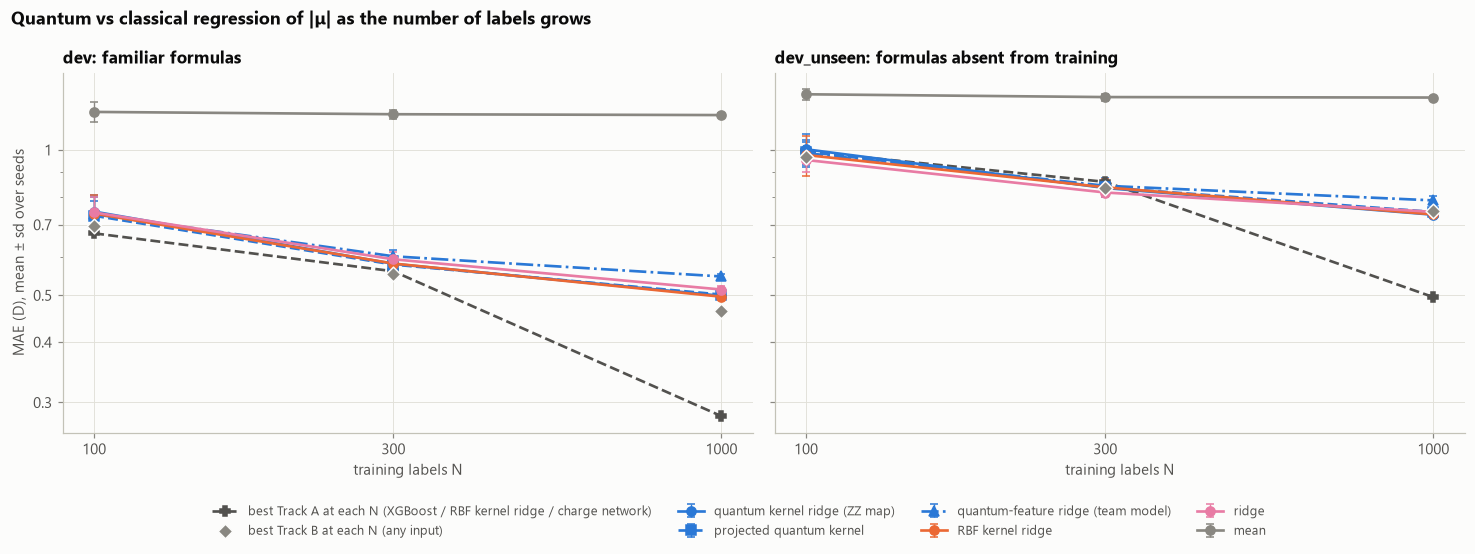

In [7]:
# Best Track A model at each N: chosen on dev (notebook 04's rule), reported on both sets for that same model.
a_mean = track_a[track_a["model"] != "mean"].groupby(["eval_set", "n_train", "model"])[["mae_D", "rmse_D"]].mean()
BEST_A = a_mean.xs("dev", level="eval_set")["mae_D"].groupby(level="n_train").idxmin().map(lambda t: t[1])
best_a = BEST_A.loc[NMAX]
FULL = int(track_a["n_train"].max())


def best_a_at(ev, n, col="mae_D"):
    m = BEST_A.loc[n]
    return m, float(a_mean.loc[(ev, n, m), col])


# Best Track B model at each N: chosen by CV MAE inside the training sets (Track B's protocol).
tb = track_b[(track_b["model"] != "mean") & track_b["n_train"].isin(SIZES)]
b_mean = tb.groupby(["eval_set", "n_train", "model", "features"])[["mae_D", "rmse_D", "cv_mae_D"]].mean()
BEST_B = b_mean.xs("dev", level="eval_set")["cv_mae_D"].groupby(level="n_train").idxmin().map(lambda t: t[1:])


def best_b_at(ev, n, col="mae_D"):
    m, f = BEST_B.loc[n]
    return m, f, float(b_mean.loc[(ev, n, m, f), col])


print("best Track A at each N (chosen on dev):", {n: BEST_A.loc[n] for n in SIZES}, f"; at the full pool ({FULL:,}):",
      BEST_A.loc[FULL])
print("best Track B at each N (chosen by CV):", {n: "{} on {}".format(*BEST_B.loc[n]) for n in SIZES})
SHOW = [HEAD, *[m for m in ("pqk", "qridge") if m != HEAD], "rbf_krr", "ridge", "mean"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)
for ax, ev in zip(axes, EVAL):
    for m in SHOW:
        s = main[(main["eval_set"] == ev) & (main["model"] == m)].groupby("n_train")["mae_D"].agg(["mean", "std"])
        ax.errorbar(s.index, s["mean"], yerr=s["std"], capsize=2.5, elinewidth=0.9, label=MODEL_LABELS[m],
                    **model_style(m))
    names = " / ".join(dict.fromkeys(MODEL_LABELS[BEST_A.loc[n]] for n in SIZES))
    ax.plot(SIZES, [best_a_at(ev, n)[1] for n in SIZES], color=INK_SECONDARY, linestyle="--", marker="P",
            label=f"best Track A at each N ({names})")
    ax.scatter(SIZES, [best_b_at(ev, n)[2] for n in SIZES], marker="D", s=46, color=MUTED, zorder=3, edgecolors=SURFACE,
               linewidths=1, label="best Track B at each N (any input)")
    ax.set(xscale="log", yscale="log", xlabel="training labels N",
           title=f"{ev}: {'familiar formulas' if ev == 'dev' else 'formulas absent from training'}")
    ax.xaxis.set_major_locator(FixedLocator(SIZES))
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}")
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_major_locator(FixedLocator([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5]))
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
    ax.yaxis.set_minor_formatter(NullFormatter())
axes[0].set_ylabel("MAE (D), mean ± sd over seeds")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8.5, bbox_to_anchor=(0.5, 0.0))  # below the panels
fig.suptitle("Quantum vs classical regression of |μ| as the number of labels grows", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0.1, 1, 1))
fig.savefig(figure_file("explore06_learning_curves.png"))
plt.show()

### 2c. Encodings and models side by side (N = 1000)
Each dot is one seed's development-set MAE; the large dot is the mean. Vertical lines: the matched RBF kernel ridge
(dashed orange), the best Track B model of any input (gray) and the best Track A model (in that model's colour), at
the same N.

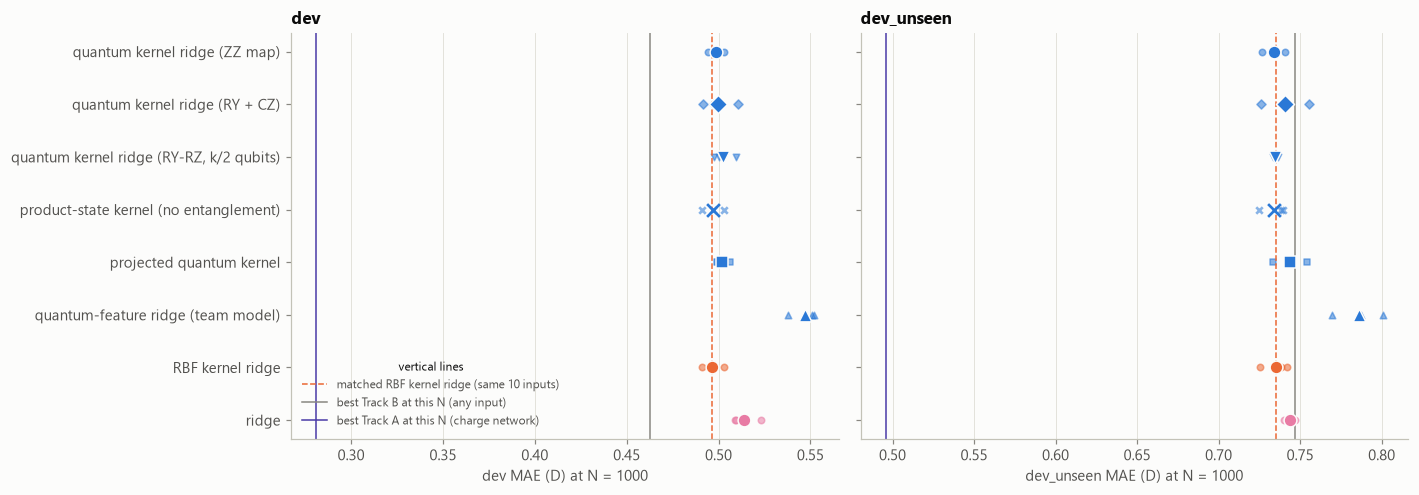

In [8]:
order = [*QMODELS, "rbf_krr", "ridge"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, ev in zip(axes, EVAL):
    sub = main[(main["eval_set"] == ev) & (main["n_train"] == NMAX)]
    for i, m in enumerate(order):
        v = sub[sub["model"] == m]["mae_D"]
        st = model_style(m)
        ax.scatter(v, np.full(len(v), i), s=18, color=st["color"], alpha=0.55, marker=st["marker"])
        ring = {} if st["marker"] in ("x", "+") else {"edgecolors": SURFACE, "linewidths": 1}  # unfilled markers have no edge
        ax.scatter([v.mean()], [i], s=70, color=st["color"], marker=st["marker"], zorder=3, **ring)
    ax.axvline(sub[sub["model"] == "rbf_krr"]["mae_D"].mean(), color=MODEL_COLORS["rbf_krr"], linewidth=1, linestyle="--",
               label="matched RBF kernel ridge (same 10 inputs)")
    ax.axvline(best_b_at(ev, NMAX)[2], color=MUTED, linewidth=1, label="best Track B at this N (any input)")
    ax.axvline(best_a_at(ev, NMAX)[1], color=MODEL_COLORS[best_a], linewidth=1,
               label=f"best Track A at this N ({MODEL_LABELS[best_a]})")
    ax.set(xlabel=f"{ev} MAE (D) at N = {NMAX}", title=ev)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(order)), [MODEL_LABELS[m] for m in order])
axes[0].invert_yaxis()
axes[0].legend(fontsize=8, loc="lower left", title="vertical lines", title_fontsize=8)
fig.tight_layout()
fig.savefig(figure_file("explore06_models_at_nmax.png"))
plt.show()

## 3. The headline numbers: the quantum model against both baselines

Per training size: the headline quantum model; its matched classical twin (RBF kernel ridge on the same 10 inputs)
with the paired per-seed difference; the best Track B model of any input at that N; the best Track A model at that N;
the best Track A model with **all** 99,198 training labels (the best classical result from Z and R); and the mean
baseline. **Beating only the matched column would say the quantum kernel is a better similarity measure on these
inputs; it would not say anyone should use it.**

In [9]:
def paired(model, ref_model, ev, col="mae_D", frame=None):
    frame = main if frame is None else frame
    p = frame[frame["eval_set"] == ev].pivot_table(index=["n_train", "seed"], columns="model", values=col)
    d = (p[model] - p[ref_model]).groupby(level="n_train")
    return d.mean(), d.std()


rows = []
for ev in EVAL:
    q = main[(main["eval_set"] == ev)]
    for n in SIZES:
        g = q[q["n_train"] == n].groupby("model")[["mae_D", "rmse_D"]]
        mean, sd = g.mean(), g.std().fillna(0)
        dm, ds = paired(HEAD, "rbf_krr", ev)
        am, a_mae = best_a_at(ev, n)
        a_rmse = best_a_at(ev, n, "rmse_D")[1]
        bm, bf, b_mae = best_b_at(ev, n)
        rows.append({"eval_set": ev, "N": n, "quantum model": MODEL_LABELS[HEAD],
                     "quantum MAE": mean.loc[HEAD, "mae_D"], "quantum MAE sd": sd.loc[HEAD, "mae_D"],
                     "quantum RMSE": mean.loc[HEAD, "rmse_D"],
                     "matched RBF KRR MAE": mean.loc["rbf_krr", "mae_D"], "matched RBF KRR RMSE": mean.loc["rbf_krr", "rmse_D"],
                     "paired Δ MAE (quantum − RBF)": dm.loc[n], "paired Δ sd": ds.fillna(0).loc[n],
                     "best Track B MAE": b_mae, "best Track B": f"{MODEL_LABELS.get(bm, bm)} on {bf}",
                     "best Track A MAE": a_mae, "best Track A RMSE": a_rmse, "best Track A": MODEL_LABELS[am],
                     f"best Track A, N = {FULL:,} MAE": best_a_at(ev, FULL)[1],
                     "mean baseline MAE": mean.loc["mean", "mae_D"]})
headline = pd.DataFrame(rows)
_ = save_result(headline, "explore06_headline", head=HEAD, best_track_a={int(n): BEST_A.loc[n] for n in SIZES},
                best_track_a_full=BEST_A.loc[FULL], smoke=SMOKE,
                label="exploratory; Z, R only; headline quantum model vs matched, best Track B and best Track A (dev sets)")
num = [c for c in headline.columns if headline[c].dtype.kind == "f"]
display(headline.set_index(["eval_set", "N"]).style.format({c: "{:+.3f}" if c.startswith("paired") else "{:.3f}" for c in num})
        .set_caption("Headline: quantum model vs the baselines (D; mean over seeds)"))

prs = []
for m in QMODELS:
    for ev in EVAL:
        for col in ("mae_D", "rmse_D"):
            dm, ds = paired(m, "rbf_krr", ev, col)
            for n in SIZES:
                prs.append({"model": m, "eval_set": ev, "metric": col, "N": n, "mean Δ": dm.loc[n], "sd Δ": ds.fillna(0).loc[n]})
pairs = pd.DataFrame(prs)
_ = save_result(pairs, "explore06_paired", reference="rbf_krr", smoke=SMOKE,
                label="paired per-seed differences, quantum model minus RBF kernel ridge on the same inputs (D)")
t = pairs[pairs["metric"] == "mae_D"].assign(v=lambda d: d["mean Δ"].map("{:+.3f}".format) + " ± " + d["sd Δ"].map("{:.3f}".format))
t = t.pivot_table(index="model", columns=["eval_set", "N"], values="v", aggfunc="first").loc[QMODELS]
t.index = t.index.map(MODEL_LABELS)
display(t.style.set_caption("paired MAE difference vs the matched RBF kernel ridge (D; negative = quantum better)"))

## 4. How many qubits? Error against the number of inputs k

The same comparison at k = 4, 6, 8, 12 and 16 PLS inputs (k = 10 is section 2). For the ZZ map and RY + CZ encoders,
k inputs means k qubits; for RY-RZ it means k/2. Models: the headline quantum model (if it is a kernel model),
QKRR with the ZZ map, the projected kernel, and the matched RBF kernel ridge. At 16 qubits each statevector has 65,536
amplitudes (1 MB per molecule): one cross-validated fit took 13–16 minutes at N = 100 on this machine, so k = 16 runs
for seed 0 at N = 100 and 300 only, with fewer parallel workers; its points carry no seed spread. The figure shows
N = 300 (with k = 16) and N = 1000.

k =  4: 0.0 min so far


k =  6: 0.0 min so far


k =  8: 0.0 min so far


k = 12: 0.0 min so far


k = 16: 0.0 min so far


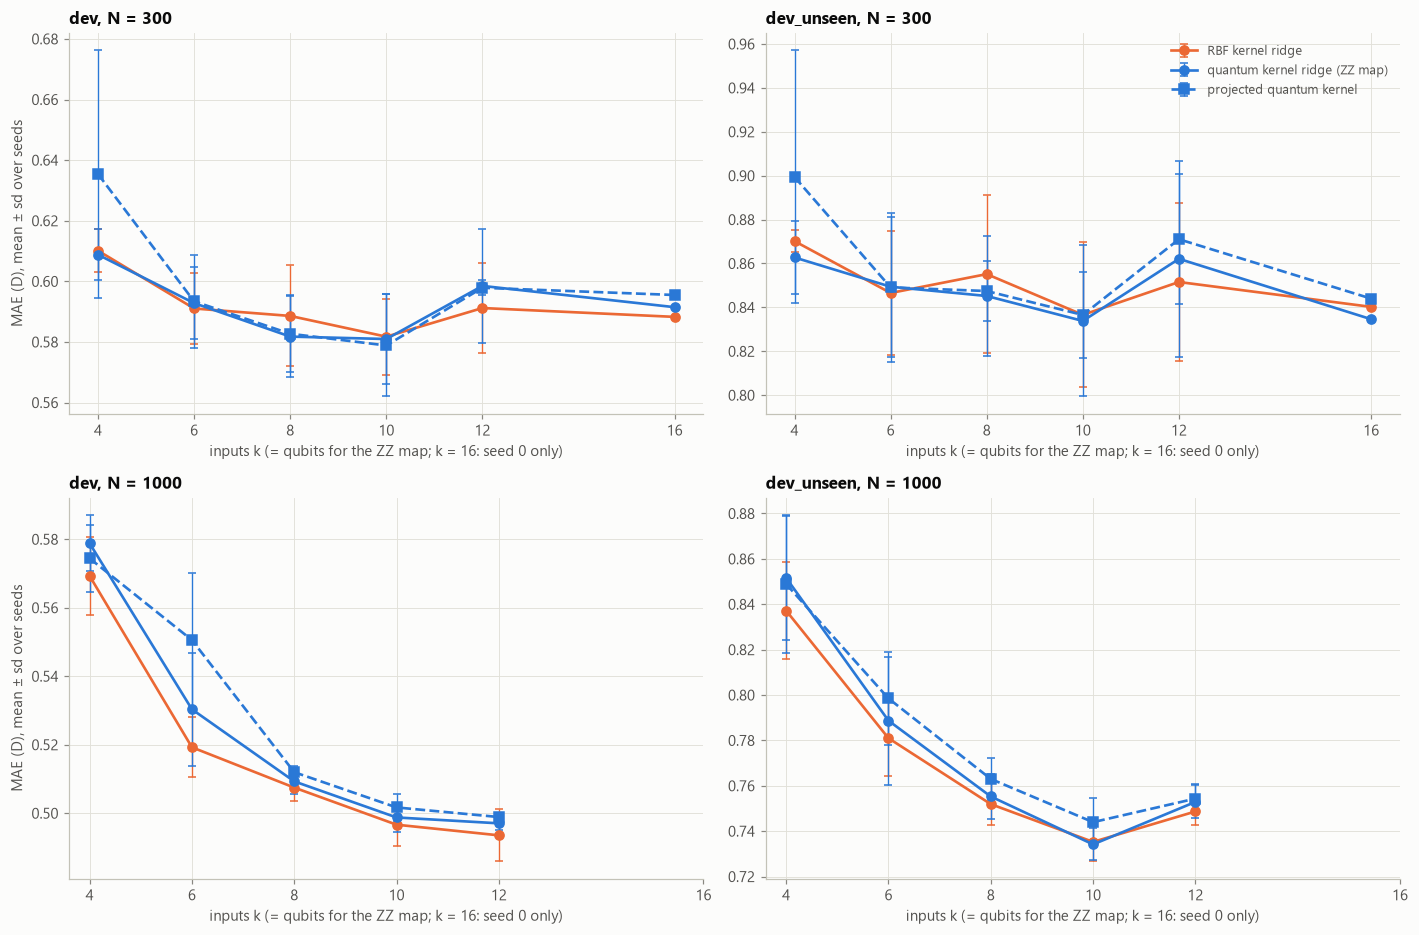

In [10]:
K_AXIS = [4] if SMOKE else [4, 6, 8, 12, 16]
K_SEEDS, K_SIZES = {16: [0]}, {16: [100, 300]}  # the costliest axis point: seed 0, N <= 300 (stated above)
AXIS_Q = list(dict.fromkeys([HEAD if HEAD in QUANTUM_KERNELS else "qkrr", "qkrr", "pqk"]))


def make_k(k):
    def make(seed, n):
        red = (RED[0], k)
        out = classical_twins(seed, XA, red, models=("rbf_krr",))
        for m in AXIS_Q:
            out[m] = KernelRidgeFitter(XA, QUANTUM_KERNELS[m], seed, scaling=SC_B, target=TG_B, reduction=red,
                                       cv_max_n=NMAX, n_jobs=3 if k >= 14 else -1)
        return out
    return make


start = time.perf_counter()
parts = []
for k in K_AXIS:
    sets = {s: {n: ids for n, ids in TRACK_B[s].items() if n in K_SIZES.get(k, SIZES)}
            for s in K_SEEDS.get(k, SEEDS) if s in TRACK_B}
    r, _ = dev_curve(make_k(k), sets, EVAL, y, cache_dir=CACHE, progress=False)
    parts.append(tidy(r, f"{RED[0]}{k}").assign(k=k))
    print(f"k = {k:2d}: {(time.perf_counter() - start) / 60:.1f} min so far", flush=True)
main_k = tidy(main[main["model"].isin(["rbf_krr", *AXIS_Q])], RED_NAME).assign(k=RED[1])
qubits = pd.concat([*parts, main_k], ignore_index=True)
_ = save_result(qubits, "explore06_qubits", models=AXIS_Q, k=K_AXIS + [RED[1]], smoke=SMOKE,
                label="exploratory; Z, R only; error vs number of PLS inputs (qubits); dev scores")

ROWS_N = [n for n in (300, NMAX) if n in SIZES] or [NMAX]
fig, axes = plt.subplots(len(ROWS_N), 2, figsize=(13, 4.3 * len(ROWS_N)), squeeze=False)
for row, n in zip(axes, ROWS_N):
    for ax, ev in zip(row, EVAL):
        sub = qubits[(qubits["eval_set"] == ev) & (qubits["n_train"] == n)]
        for m in ["rbf_krr", *AXIS_Q]:
            s = sub[sub["model"] == m].groupby("k")["mae_D"].agg(["mean", "std"])
            ax.errorbar(s.index, s["mean"], yerr=s["std"].fillna(0), capsize=2.5, elinewidth=0.9, label=MODEL_LABELS[m],
                        **model_style(m))
        ax.set(xlabel="inputs k (= qubits for the ZZ map; k = 16: seed 0 only)", title=f"{ev}, N = {n}")
        ax.set_xticks(sorted(qubits["k"].unique()))
    row[0].set_ylabel("MAE (D), mean ± sd over seeds")
axes[0][1].legend(fontsize=8.5)
fig.tight_layout()
fig.savefig(figure_file("explore06_qubits.png"))
plt.show()
tq = qubits[qubits["eval_set"] == "dev"].groupby(["model", "k", "n_train"])["mae_D"].mean().unstack("n_train")
tq = tq.reset_index().assign(model=lambda d: d["model"].map(MODEL_LABELS)).set_index(["model", "k"])
display(tq.style.format("{:.3f}").set_caption("dev MAE (D) by number of inputs k and N (mean over seeds)"))

## 5. Which inputs? Reduction method, and composition only

At k = 10: PCA (unsupervised: directions of largest variance) and top-10 by mutual information (supervised feature
selection) against section 2's PLS (supervised directions). Then the brief's ablation, **composition only**: the five
atom counts (C, H, N, O, F), one per qubit, with no geometry at all.

In [11]:
VARIANTS = {"pca10": (XA, ("pca", 10)), "kbest10": (XA, ("kbest", 10)), "composition": (XC, None)}
INPUT_Q = list(dict.fromkeys([HEAD if HEAD in QUANTUM_KERNELS else "qkrr", "qkrr", "pqk"]))


def make_inputs(seed, n):
    out = {}
    for v, (frame, red) in VARIANTS.items():
        for m, f in classical_twins(seed, frame, red, models=("rbf_krr",)).items():
            out[f"{m}|{v}"] = f
        for m in INPUT_Q:
            out[f"{m}|{v}"] = KernelRidgeFitter(frame, QUANTUM_KERNELS[m], seed, scaling=SC_B, target=TG_B,
                                                reduction=red, cv_max_n=NMAX)
    return out


start = time.perf_counter()
inputs, _ = dev_curve(make_inputs, TRACK_B, EVAL, y, cache_dir=CACHE, progress=False)
inputs[["model", "features"]] = inputs["model"].str.split("|", expand=True)
inputs["cv_mae_D"] = inputs["details"].map(lambda d: json.loads(d).get("tuning_mae_D", np.nan))
inputs = pd.concat([inputs, main[main["model"].isin(["rbf_krr", *INPUT_Q])]], ignore_index=True)
print(f"input variants in {(time.perf_counter() - start) / 60:.1f} min")
_ = save_result(inputs, "explore06_inputs", variants=list(VARIANTS), smoke=SMOKE,
                label="exploratory; Z, R only; reduction methods and composition-only inputs; dev scores")
ti = inputs[inputs["eval_set"] == "dev"].groupby(["features", "model", "n_train"])["mae_D"].mean().unstack("n_train")
ti = ti.reset_index().assign(model=lambda d: d["model"].map(MODEL_LABELS)).set_index(["features", "model"])
display(ti.style.format("{:.3f}").set_caption("dev MAE (D) by input variant (mean over seeds)"))
tu = inputs[inputs["eval_set"] == "dev_unseen"].groupby(["features", "model", "n_train"])["mae_D"].mean().unstack("n_train")
tu = tu.reset_index().assign(model=lambda d: d["model"].map(MODEL_LABELS)).set_index(["features", "model"])
display(tu.style.format("{:.3f}").set_caption("dev_unseen MAE (D) by input variant (mean over seeds)"))

input variants in 0.0 min


## 6. Inside the kernels

**6a. Concentration.** For each angle scale γ, the mean and spread of the off-diagonal entries of the ZZ-map
fidelity kernel (solid) and of the projected kernel on the same states (dashed, γ_p = 1/n) on 500 molecules of
S_(0,1000) (PLAN §7.3), with each kernel's alignment with the target. When the spread collapses, the kernel cannot tell
molecules apart: everything looks identical (small γ) or orthogonal (large γ). More qubits push the collapse to
smaller γ: this is **exponential concentration**, the main known obstacle for fidelity kernels. The ticks mark the γ
values CV chose at N = 1000 (k = 10).

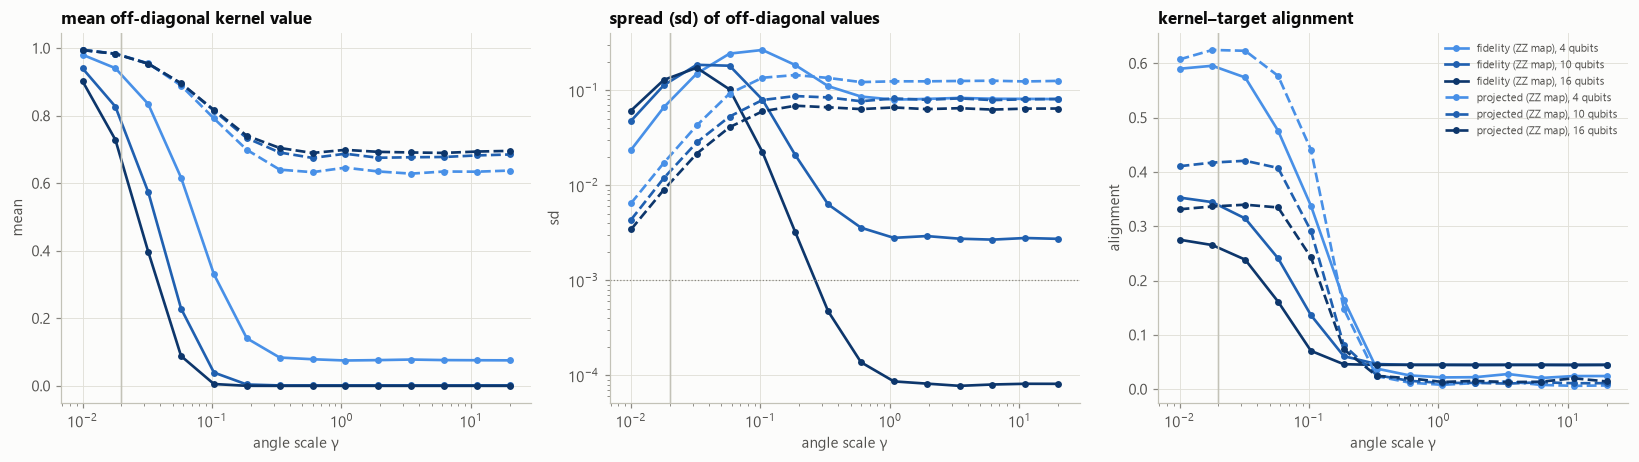

In [12]:
sub_ids = splits.train[0][NMAX][:500]
ys = y.loc[sub_ids].to_numpy()
GAMMAS = np.logspace(-2, 1.3, 14)
conc = []
for k in ([4] if SMOKE else [4, 10, 16]):
    p = feature_prefix(SC_B, (RED[0], k))
    zz = target_transformer(TG_B).fit(ys[:, None]).transform(ys[:, None]).ravel()
    Xk = p.fit(XA.loc[sub_ids].to_numpy(), zz).transform(XA.loc[sub_ids].to_numpy())
    for kind, kern in (("fidelity (ZZ map)", FidelityKernel("zz")), ("projected (ZZ map)", ProjectedKernel("zz"))):
        for g in GAMMAS:
            E = kern.embed(Xk, {"gamma": g})
            K = kern.gram(E, E, {"gamma_p": 1.0 / kern.qubits(k)} if kind.startswith("projected") else {})
            mean, sd = offdiag_stats(K)
            conc.append({"kernel": kind, "k": k, "gamma": g, "offdiag_mean": mean, "offdiag_sd": sd,
                         "alignment": kernel_target_alignment(K, zz)})
conc = pd.DataFrame(conc)
_ = save_result(conc, "explore06_concentration", n_molecules=len(sub_ids), smoke=SMOKE,
                label="kernel concentration and kernel-target alignment vs angle scale (500 molecules of S_(0,1000))")

ks = sorted(conc["k"].unique())
shades = [SEQUENTIAL(x) for x in np.linspace(0.45, 1.0, len(ks))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for kind, ls in (("fidelity (ZZ map)", "-"), ("projected (ZZ map)", "--")):
    for k, col in zip(ks, shades):
        s = conc[(conc["kernel"] == kind) & (conc["k"] == k)]
        lab = f"{kind}, {k} qubits"
        axes[0].plot(s["gamma"], s["offdiag_mean"], color=col, linestyle=ls, marker="o", markersize=3.5, label=lab)
        axes[1].plot(s["gamma"], s["offdiag_sd"], color=col, linestyle=ls, marker="o", markersize=3.5, label=lab)
        axes[2].plot(s["gamma"], s["alignment"], color=col, linestyle=ls, marker="o", markersize=3.5, label=lab)
chosen_g = [json.loads(d)["params"]["gamma"] for d in main[(main["model"] == "qkrr") & (main["n_train"] == NMAX)
                                                              & (main["eval_set"] == "dev")]["details"]]
for ax, title, yl in zip(axes, ["mean off-diagonal kernel value", "spread (sd) of off-diagonal values", "kernel–target alignment"],
                         ["mean", "sd", "alignment"]):
    ax.set(xscale="log", xlabel="angle scale γ", title=title, ylabel=yl)
    for g in chosen_g:
        ax.axvline(g, color=AXIS, linewidth=0.8)
axes[1].set_yscale("log")
axes[1].axhline(1e-3, color=MUTED, linewidth=0.8, linestyle=":")
axes[2].legend(fontsize=7.5)
fig.tight_layout()
fig.savefig(figure_file("explore06_concentration.png"))
plt.show()

**6b. Effective number of parameters, alignment and spectrum at the chosen settings.** For kernel ridge,
df = tr(S) (ESL §7.6) measures how much flexibility the fitted model uses. It is computed the same way for the
quantum kernels (stored by the fitter) and for RBF kernel ridge (recomputed here at its chosen γ and α), *given the
fitted PLS inputs*. PLS chose those inputs using the target, so both numbers understate the full flexibility (notebook
04 uses a Monte-Carlo estimate for that); the convention is the same for both, so they compare. The participation
ratio of the kernel's eigenvalues counts how many directions the kernel effectively spans.

,effective_df,alignment,kernel_participation_ratio,offdiag_mean,offdiag_sd
model,,,,,
projected quantum kernel,68.412,0.318,1.616,0.837,0.081
quantum kernel ridge (ZZ map),71.375,0.284,1.525,0.799,0.133
product-state kernel (no entanglement),67.673,0.247,1.426,0.829,0.117
quantum kernel ridge (RY + CZ),76.310,0.144,1.646,0.785,0.136
"quantum kernel ridge (RY-RZ, k/2 qubits)",43.756,0.235,1.364,0.856,0.104
RBF kernel ridge,71.653,0.247,1.421,0.831,0.115


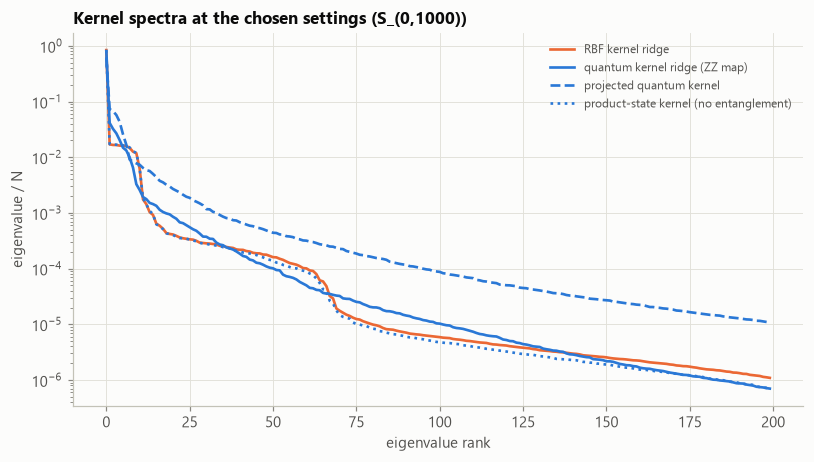

In [13]:
rows = []
for seed in SEEDS:
    ids = splits.train[seed][NMAX]
    yy = y.loc[ids].to_numpy()
    zt = target_transformer(TG_B).fit(yy[:, None]).transform(yy[:, None]).ravel()
    Xs = feature_prefix(SC_B, RED).fit(XA.loc[ids].to_numpy(), zt).transform(XA.loc[ids].to_numpy())
    d = json.loads(main[(main["model"] == "rbf_krr") & (main["seed"] == seed) & (main["n_train"] == NMAX)]["details"].iloc[0])["params"]
    K = rbf_kernel(Xs, gamma=d["regressor__model__gamma"])
    lam = kernel_spectrum(K)
    rows.append({"seed": seed, "model": "rbf_krr", "effective_df": kernel_ridge_df(K, d["regressor__model__alpha"]),
                 "alignment": kernel_target_alignment(K, zt), "kernel_participation_ratio": participation_ratio(lam),
                 "offdiag_mean": offdiag_stats(K)[0], "offdiag_sd": offdiag_stats(K)[1]})
    for m in QUANTUM_KERNELS:
        det = json.loads(main[(main["model"] == m) & (main["seed"] == seed) & (main["n_train"] == NMAX)]["details"].iloc[0])
        rows.append({"seed": seed, "model": m, **{k: det.get(k) for k in ("effective_df", "alignment",
                     "kernel_participation_ratio", "offdiag_mean", "offdiag_sd")}})
dfk = pd.DataFrame(rows)
_ = save_result(dfk, "explore06_kernel_diagnostics", n_train=NMAX, smoke=SMOKE,
                label="effective df (given the fitted PLS inputs), alignment, spectrum participation ratio, concentration")
t = dfk.groupby("model")[["effective_df", "alignment", "kernel_participation_ratio", "offdiag_mean", "offdiag_sd"]].mean()
t.index = t.index.map(MODEL_LABELS)
display(t.style.format("{:.3f}").set_caption(f"kernels at their chosen settings, S_(s,{NMAX}) (mean over seeds)"))

# Spectra of the headline quantum kernel and the RBF twin, seed 0
ids = splits.train[0][NMAX]
yy = y.loc[ids].to_numpy()
zt = target_transformer(TG_B).fit(yy[:, None]).transform(yy[:, None]).ravel()
Xs = feature_prefix(SC_B, RED).fit(XA.loc[ids].to_numpy(), zt).transform(XA.loc[ids].to_numpy())
fig, ax = plt.subplots(figsize=(7.5, 4.3))
d = json.loads(main[(main["model"] == "rbf_krr") & (main["seed"] == 0) & (main["n_train"] == NMAX)]["details"].iloc[0])["params"]
ax.plot(kernel_spectrum(rbf_kernel(Xs, gamma=d["regressor__model__gamma"]))[:200], label=MODEL_LABELS["rbf_krr"], **{**model_style("rbf_krr"), "marker": None})
for m in dict.fromkeys([HEAD if HEAD in QUANTUM_KERNELS else "qkrr", "qkrr", "pqk", "qkrr_product"]):
    p = json.loads(main[(main["model"] == m) & (main["seed"] == 0) & (main["n_train"] == NMAX)]["details"].iloc[0])["params"]
    kern = QUANTUM_KERNELS[m]
    E = kern.embed(Xs, {"gamma": p["gamma"]})
    ax.plot(kernel_spectrum(kern.gram(E, E, p))[:200], label=MODEL_LABELS[m], **{**model_style(m), "marker": None})
ax.set(yscale="log", xlabel="eigenvalue rank", ylabel="eigenvalue / N",
       title=f"Kernel spectra at the chosen settings (S_(0,{NMAX}))")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(figure_file("explore06_spectra.png"))
plt.show()

## 7. Is the team model's quantum part replaceable by a formula?

For the ZZ map with two passes, each qubit's ⟨Z⟩ has an exact closed form (`zz_readout_closed_form`):
⟨Z_k⟩ = cos(2a_k) · Π_{j neighbour of k} cos(2(π − a_k)(π − a_j)), with a = γ·x. If the simulated circuit and the
formula agree, the team's quantum-feature ridge is ridge regression on a fixed classical feature map, computable on a
laptop at any size. That is a property of this circuit (shallow, Z readout), not a flaw in the implementation.

In [14]:
Xd = pre.transform(XA.loc[splits.dev].to_numpy())
g = json.loads(main[(main["model"] == "qridge") & (main["seed"] == 0) & (main["n_train"] == NMAX)]["details"].iloc[0])["params"]["regressor__model__gamma"]
sim = QuantumFeatureTransformer(gamma=g, reps=2, simulation_method="batched").fit(Xd).transform(Xd)
est20 = QuantumFeatureTransformer(gamma=g, reps=2, simulation_method="statevector").fit(Xd[:20]).transform(Xd[:20])
formula = zz_readout_closed_form(g * Xd)
print(f"chosen γ = {g:.3f}; max |formula − batched simulation| over {len(Xd):,} dev molecules: {np.abs(formula - sim).max():.1e}")
print(f"max |formula − Qiskit Estimator| on 20 molecules: {np.abs(formula[:20] - est20).max():.1e}")

chosen γ = 0.020; max |formula − batched simulation| over 5,000 dev molecules: 2.9e-14
max |formula − Qiskit Estimator| on 20 molecules: 3.3e-15


## 8. Familiar vs new formulas

The brief asks whether a model works on formulas absent from training. `dev_unseen` holds 26 whole formulas that are
in no training set. The penalty is MAE(dev_unseen) − MAE(dev), at each N (mean over seeds).

In [15]:
pen = main.groupby(["model", "n_train", "eval_set"])["mae_D"].mean().unstack("eval_set")
pen = (pen["dev_unseen"] - pen["dev"]).unstack("n_train").loc[ORDER]
pen.index = pen.index.map(MODEL_LABELS)
display(pen.style.format("{:+.3f}").set_caption("new-formula penalty MAE(dev_unseen) − MAE(dev) (D)"))

n_train,100,300,1000
model,,,
mean,+0.105,+0.101,+0.103
ridge,+0.211,+0.223,+0.230
RBF kernel ridge,+0.238,+0.255,+0.239
quantum kernel ridge (ZZ map),+0.258,+0.253,+0.235
quantum kernel ridge (RY + CZ),+0.246,+0.249,+0.241
"quantum kernel ridge (RY-RZ, k/2 qubits)",+0.283,+0.226,+0.232
product-state kernel (no entanglement),+0.244,+0.254,+0.237
projected quantum kernel,+0.261,+0.258,+0.242
quantum-feature ridge (team model),+0.249,+0.241,+0.239


## 9. End-to-end invariance of the quantum model

PLAN §8.2 and the brief: rotate, translate and relabel 50 development molecules, recompute every descriptor from the
moved coordinates, and predict again with the headline quantum model trained on S_(0,1000). A physically sensible
|μ| predictor must not change. The negative control is the same quantum kernel on raw, zero-padded coordinates (PCA to
10 inputs), which must change.

In [16]:
table = load_qm9_table().set_index("id")
probe_ids = np.random.default_rng(2026).choice(splits.dev, size=50, replace=False)
ids0 = splits.train[0][NMAX]


def legal_features(mols):
    t = pd.DataFrame({"id": np.arange(len(mols)), "Z": [m[0] for m in mols], "R": [m[1] for m in mols]})
    return pd.concat([feature_frame(t, name) for name in MODEL_DESCRIPTORS], axis=1)[SETS["all_legal"]].to_numpy()


def raw_frame(ids):
    return pd.DataFrame(np.stack([raw_coordinates(np.asarray(z), np.asarray(r)) for z, r in table.loc[ids, ["Z", "R"]].itertuples(index=False)]),
                        index=ids)


INV_M = HEAD if HEAD in QUANTUM_KERNELS else "qkrr"
kern_head = QUANTUM_KERNELS[INV_M]
model = KernelRidgeFitter(XA, kern_head, 0, scaling=SC_B, target=TG_B, reduction=RED, cv_max_n=NMAX).fit(ids0, y.loc[ids0])
raw_ids = np.concatenate([ids0, probe_ids])
RAW = raw_frame(raw_ids)
control = KernelRidgeFitter(RAW, kern_head, 0, scaling="standard", target=TG_B, reduction=("pca", 10), cv_max_n=NMAX).fit(ids0, y.loc[ids0])
mols = [(np.asarray(z), np.asarray(r)) for z, r in table.loc[probe_ids, ["Z", "R"]].itertuples(index=False)]
base_feats = legal_features(mols)
print(f"recomputed vs stored descriptors: max |Δ| = {np.abs(base_feats - XA.loc[probe_ids].to_numpy()).max():.1e}")
base = model.predict_X(base_feats)
raw_base = control.predict_X(RAW.loc[probe_ids].to_numpy())
rows = []
for name, tf in TRANSFORMS.items():
    rng = np.random.default_rng([2026, len(name)])
    moved = [tf(z, r, rng) for z, r in mols]
    change = np.abs(model.predict_X(legal_features(moved)) - base)
    raw_moved = np.stack([raw_coordinates(z, r) for z, r in moved])
    raw_change = np.abs(control.predict_X(raw_moved) - raw_base)
    rows.append({"transform": name, f"{MODEL_LABELS[INV_M]}: max |Δμ̂| (D)": change.max(),
                 "mean |Δμ̂| (D)": change.mean(), "negative control (raw coordinates): max |Δμ̂| (D)": raw_change.max()})
inv = pd.DataFrame(rows).set_index("transform")
display(inv.style.format("{:.2e}").set_caption("end-to-end invariance on 50 development molecules"))
assert (inv.iloc[:, 0] < 1e-6).all(), "the quantum model is not invariant"
assert (inv.iloc[:, 2] > 1e-2).all(), "the negative control must fail"
_ = save_result(inv.reset_index(), "explore06_invariance", model=INV_M, n_molecules=len(probe_ids), smoke=SMOKE,
                label="exploratory; quantum model trained on S_(0,1000); development molecules")

recomputed vs stored descriptors: max |Δ| = 3.0e-05


,quantum kernel ridge (ZZ map): max |Δμ̂| (D),mean |Δμ̂| (D),negative control (raw coordinates): max |Δμ̂| (D)
transform,,,
rotation,4.13e-13,9.61e-14,1.29e+00
translation,3.70e-13,1.16e-13,1.33e+00
permutation,3.25e-13,1.01e-13,1.12e+00


## 10. Beyond the quantum-comparable sizes (simulator only)

On a simulator nothing stops the quantum kernel at N = 1000, so here it follows the learning curve to N = 3,000
(3 seeds) and 10,000 (seed 0), next to RBF kernel ridge on the same inputs (tuned on an inner validation split above
N = 1000, as in notebook 04). On hardware this is out of reach: the fidelity kernel at N = 10,000 needs ~5 × 10⁷
overlap circuits (notebook 07).

extended sizes in 0.0 min


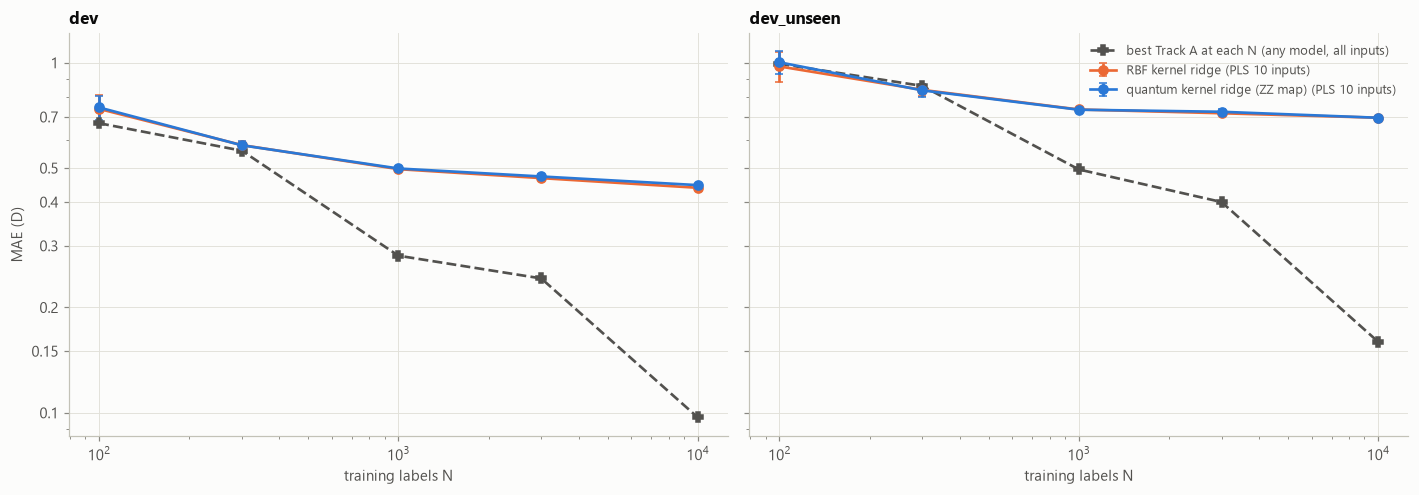

In [17]:
EXT = {} if SMOKE else {0: {3000: splits.train[0][3000], 10000: splits.train[0][10000]},
                        1: {3000: splits.train[1][3000]}, 2: {3000: splits.train[2][3000]}}
EXT_Q = HEAD if HEAD in QUANTUM_KERNELS else "qkrr"


def make_ext(seed, n):
    out = classical_twins(seed, XA, RED, models=("rbf_krr",))
    out[EXT_Q] = KernelRidgeFitter(XA, QUANTUM_KERNELS[EXT_Q], seed, scaling=SC_B, target=TG_B, reduction=RED,
                                   cv_max_n=NMAX, n_jobs=3 if n > 5000 else -1)
    return out


if EXT:
    start = time.perf_counter()
    ext, _ = dev_curve(make_ext, EXT, EVAL, y, cache_dir=CACHE, progress=False)
    ext = tidy(ext, RED_NAME)
    print(f"extended sizes in {(time.perf_counter() - start) / 60:.1f} min")
    ext = pd.concat([ext, main[main["model"].isin(["rbf_krr", EXT_Q])]], ignore_index=True)
    _ = save_result(ext, "explore06_extended", model=EXT_Q, smoke=SMOKE,
                    label="exploratory, simulator only; quantum kernel and RBF kernel ridge on PLS(10) inputs to N = 10,000")
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
    for ax, ev in zip(axes, EVAL):
        for m in ["rbf_krr", EXT_Q]:
            s = ext[(ext["eval_set"] == ev) & (ext["model"] == m)].groupby("n_train")["mae_D"].agg(["mean", "std"])
            ax.errorbar(s.index, s["mean"], yerr=s["std"].fillna(0), capsize=2.5, label=f"{MODEL_LABELS[m]} (PLS 10 inputs)", **model_style(m))
        ns = [n for n in sorted(BEST_A.index) if n <= 10000]
        ax.plot(ns, [best_a_at(ev, n)[1] for n in ns], color=INK_SECONDARY, linestyle="--", marker="P",
                label="best Track A at each N (any model, all inputs)")
        ax.set(xscale="log", yscale="log", xlabel="training labels N", title=ev)
        ax.yaxis.set_major_locator(FixedLocator([0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]))
        ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
        ax.yaxis.set_minor_formatter(NullFormatter())
    axes[0].set_ylabel("MAE (D)")
    axes[1].legend(fontsize=8.5)
    fig.tight_layout()
    fig.savefig(figure_file("explore06_extended.png"))
    plt.show()
    te = ext[ext["eval_set"] == "dev"].groupby(["model", "n_train"])["mae_D"].agg(["mean", "std", "count"])
    display(te.rename(index=MODEL_LABELS, level=0).style.format({"mean": "{:.3f}", "std": "{:.3f}"})
            .set_caption("dev MAE (D) on PLS(10) inputs, extended sizes"))

## Summary

1. **Headline quantum model (chosen by CV, as pre-registered): quantum kernel ridge with the ZZ feature map** on
   10 qubits (mean CV MAE at N = 1000: 0.4976 D, against 0.4984 D for RBF kernel ridge). Development MAE 0.745 /
   0.581 / 0.499 D at N = 100 / 300 / 1000 (RMSE 0.779 D and R² 0.738 at N = 1000); on formulas absent from training
   1.003 / 0.834 / 0.734 D.
2. **It ties its classical twin.** Paired per-seed differences against RBF kernel ridge on the same 10 inputs:
   +0.007 ± 0.011, −0.001 ± 0.004 and +0.002 ± 0.002 D on `dev` at N = 100 / 300 / 1000. Every quantum kernel lands
   within 0.013 D of the twin at every N (RY + CZ 0.500 D, RY-RZ on 5 qubits 0.502 D, projected kernel 0.502 D at
   N = 1000). **Entanglement contributes nothing measurable:** the product-state control (no entangling gate; its
   kernel is the classical Π cos²(γΔx/2)) scores 0.497 D, +0.000 ± 0.001 D from the twin, and its kernel spectrum lies
   on top of RBF's.
3. **Against the best classical models it is not competitive.** At N = 1000: the best Track B model (RBF kernel ridge
   on all 188 features, chosen by CV) 0.463 D; the best Track A model (the latent-charge network) 0.281 D; and with all
   99,198 labels 0.042 D. At N = 100 the best Track A model (XGBoost) reaches 0.672 D against 0.745 D. On new formulas
   at N = 1000 the 10-input models (quantum 0.734 D, twin 0.735 D) match the best Track B model (0.747 D) but stay far
   from the charge network (0.496 D).
4. **The team's quantum-feature ridge is the weakest model:** 0.547 D at N = 1000, worse than plain ridge on the same
   inputs (0.514 D; paired +0.050 ± 0.014 D vs the twin). Its ⟨Z⟩ readouts equal a classical closed form to 2.9 × 10⁻¹⁴
   over 5,000 molecules, so it is ridge regression on a fixed classical feature map of 10 numbers; CV chose the smallest
   angle scale (γ = 0.020) at every N = 1000 seed.
5. **Qubits and inputs move quantum and classical together.** Error falls with the number of inputs up to k = 12 for
   every kernel (QKRR 0.579 → 0.497 D, RBF 0.569 → 0.494 D, N = 1000), with QKRR within 0.011 D of RBF at every k; at
   16 qubits (seed 0, N = 300) QKRR 0.591 D vs RBF 0.588 D. PLS inputs beat top-10 by mutual information and PCA for
   both (QKRR 0.499 / 0.568 / 0.706 D; RBF 0.497 / 0.551 / 0.698 D), and composition alone gives 0.986 D for both.
6. **Why they tie: CV steers the quantum kernel into its classical-looking regime.** For the ZZ map at N = 1000, CV
   chose the smallest angle scale in the grid for all three seeds; kernel–target alignment is highest there and
   collapses at larger γ. At the chosen settings the two kernels have the same flexibility (effective df 71.4 vs 71.7)
   and similar spectra (participation ratio 1.53 vs 1.42). At larger γ the fidelity kernel **concentrates**: at γ = 1
   its mean off-diagonal entry is 0.076 on 4 qubits, 0.0014 on 10 and ≈ 0 on 16 (spread 8 × 10⁻⁵ at the largest γ on 16
   qubits, below the 10⁻³ flag). The projected kernel does not concentrate (mean 0.64–0.70) but is no more accurate.
7. **New formulas are equally hard for quantum and classical:** the penalty MAE(dev_unseen) − MAE(dev) at N = 1000 is
   +0.235 D for QKRR and +0.239 D for its twin (+0.23 to +0.24 D for every 10-input model).
8. **The quantum model is invariant, and the simulator is right.** Rotating, translating and relabeling 50
   development molecules and recomputing their descriptors changes QKRR's predictions by ≤ 4.1 × 10⁻¹³ D; the same
   quantum kernel on raw coordinates (negative control) changes by 1.1–1.3 D. The batched statevectors match Qiskit's
   `Statevector` to 6.3 × 10⁻¹⁴ on real inputs, 12× faster for the ZZ map.
9. **More labels on a simulator do not change the picture:** QKRR 0.473 D at N = 3,000 and 0.447 D at N = 10,000
   (seed 0) against RBF kernel ridge 0.468 and 0.439 D on the same inputs, while the best Track A model reaches 0.097 D
   at N = 10,000.

**Carried forward:** notebook 07 shows what these models would cost on hardware and that the settings which make QKRR
match RBF kernel ridge cannot be resolved with finite shots. The honest conclusion for the brief: a team-built
quantum kernel regressor works, generalizes like its classical twin, and is invariant by construction, but nothing in
it beats a classical kernel, and accurate dipoles from Z and R come from physics-structured classical models.